Para evitar el sobreajuste identificado en versiones previas, se incorporaron diversas estrategias de regularización:

Penalización L2 en todos los pesos (kernel_regularizer=l2(1e-3)).

Dropout y SpatialDropout2D (0.2–0.3) para reducir coadaptación entre neuronas y filtros.

Recurrent Dropout (0.2) en las capas ConvLSTM2D para regularizar los estados temporales.

Tasa de aprendizaje inicial baja (1e-4) con control del gradiente mediante clipnorm=1.0.

Pérdida Huber, más robusta frente a valores atípicos.

Esquema de aprendizaje adaptativo mediante cosine decay, ReduceLROnPlateau y EarlyStopping con restauración de los mejores pesos.

Estas modificaciones buscan equilibrar la capacidad de generalización y la estabilidad del entrenamiento, reduciendo la brecha entre las métricas de entrenamiento y validación observadas en los experimentos previos. En conjunto, el modelo ofrece una arquitectura más robusta y generalizable para tareas de predicción espacio-temporal basadas en secuencias de imágenes.

In [ ]:
import os
import numpy as np
from PIL import Image
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, ConvLSTM2D, Conv2D, TimeDistributed,
    Add, Activation, BatchNormalization, Dropout, SpatialDropout2D
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, LearningRateScheduler, ReduceLROnPlateau
from tensorflow.keras.metrics import RootMeanSquaredError, MeanAbsolutePercentageError
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
import matplotlib.pyplot as plt

def resize_npy_images(d_original, d_reducida, new_size=(480, 480)):
    print(f"Redimensionando imágenes en {d_original}...")

    if not os.path.exists(d_reducida):
        os.makedirs(d_reducida)

    processed_count = 0
    for filename in os.listdir(d_original):
        if filename.lower().endswith('.npy'):
            img_path = os.path.join(d_original, filename)
            img_array = np.load(img_path)
            img_resized = np.array(Image.fromarray(img_array).resize(new_size, Image.LANCZOS))
            output_path = os.path.join(d_reducida, filename)
            np.save(output_path, img_resized)
            processed_count += 1

    print(f"Procesadas {processed_count} imágenes")
    return processed_count

def mostrar_resultados(X, y, y_pred, n=5, cmap='viridis',
                       titulo_general="Comparación de Resultados",
                       xlabel="Eje X (pixeles)", ylabel="Eje Y (pixeles)"):
    n = min(n, len(X))

    fig, axs = plt.subplots(n, 3, figsize=(12, 3 * n))
    fig.suptitle(titulo_general, fontsize=16, y=1.02)

    for i in range(n):
        axs[i, 0].imshow(X[i, ..., 0], cmap=cmap)
        axs[i, 0].set_title(f'Entrada t={i}')
        axs[i, 0].set_xlabel(xlabel)
        axs[i, 0].set_ylabel(ylabel)

        axs[i, 1].imshow(y[i, ..., 0], cmap=cmap)
        axs[i, 1].set_title(f'Real t+1={i+1}')
        axs[i, 1].set_xlabel(xlabel)
        axs[i, 1].set_ylabel(ylabel)

        axs[i, 2].imshow(y_pred[i, ..., 0], cmap=cmap)
        axs[i, 2].set_title(f'Predicción t+1={i+1}')
        axs[i, 2].set_xlabel(xlabel)
        axs[i, 2].set_ylabel(ylabel)

    plt.tight_layout()
    plt.show()

In [ ]:
# =====================================================
# CONFIGURACIÓN DE RUTAS BANDA 13
# =====================================================

d13_reducida = '/home/jhon/bandas/banda13/ene_oct_10m_reducida'
d9_reducida = '/home/jhon/bandas/banda9/ene_oct_10m_reducida'

import tensorflow as tf
import numpy as np
import os

def generar_dataset_npy(ruta_banda13, ruta_banda9, timesteps=3, batch_size=1):
    """Crea un dataset eficiente que genera secuencias (X, y) desde archivos .npy de ambas bandas."""
    archivos_13 = sorted([os.path.join(d13_reducida, f) for f in os.listdir(d13_reducida) if f.endswith('.npy')])
    archivos_9  = sorted([os.path.join(d9_reducida,  f) for f in os.listdir(d9_reducida)  if f.endswith('.npy')])

    # Asegurar que ambas bandas tengan el mismo número de frames
    n_frames = min(len(archivos_13), len(archivos_9))
    archivos_13, archivos_9 = archivos_13[:n_frames], archivos_9[:n_frames]

    def cargar_secuencia(idx):
        # Secuencia temporal
        start = idx
        end = idx + timesteps

        # Cargar timesteps para ambas bandas
        seq_13 = [np.load(archivos_13[i]).astype(np.float32) for i in range(start, end)]
        seq_9  = [np.load(archivos_9[i]).astype(np.float32) for i in range(start, end)]
        seq_13 = np.stack(seq_13, axis=0)[..., np.newaxis]
        seq_9  = np.stack(seq_9, axis=0)[..., np.newaxis]

        # Combinar las bandas → (t, H, W, 2)
        X = np.concatenate([seq_13, seq_9], axis=-1)

        # Frame siguiente como salida (solo siguiente timestep)
        y13 = np.load(archivos_13[end]).astype(np.float32)[..., np.newaxis]
        y9  = np.load(archivos_9[end]).astype(np.float32)[..., np.newaxis]
        y = np.concatenate([y13, y9], axis=-1)

        return X, y

    # Crear índices de inicio de secuencias válidas
    n_seq = n_frames - timesteps - 1
    idxs = np.arange(n_seq, dtype=np.int32)

    # Crear dataset de índices
    ds = tf.data.Dataset.from_tensor_slices(idxs)

    # Mapear a datos (usando py_function para no cargar todo en RAM)
    ds = ds.map(
        lambda i: tf.py_function(
            func=lambda j: cargar_secuencia(int(j.numpy())),
            inp=[i],
            Tout=(tf.float32, tf.float32)
        ),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    # Optimización
    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds, n_seq

print("=" * 50)
print("CREANDO DATASETS EFICIENTES")
print("=" * 50)

timesteps = 3
batch_size = 1
porc_validacion = 0.2

# Crear dataset total
dataset, total_secuencias = generar_dataset_npy(d13_reducida, d9_reducida, timesteps=timesteps, batch_size=batch_size)

# Calcular tamaño de entrenamiento y validación
n_val = int(total_secuencias * porc_validacion)
n_train = total_secuencias - n_val

# Dividir dataset
train_ds = dataset.take(n_train)
val_ds = dataset.skip(n_train)

print(f"✅ Dataset creado:")
print(f"   - Total de secuencias: {total_secuencias}")
print(f"   - Entrenamiento: {n_train}")
print(f"   - Validación: {n_val}")





# =====================================================
# PARÁMETROS GENERALES
# =====================================================
semilla = 42
tf.random.set_seed(semilla)

# =====================================================
# FUNCIÓN DE DECAY COSENO
# =====================================================
# Parámetros base
initial_lr = 1e-4       # LR máximo
min_lr = 1e-6           # LR mínimo
epochs_total = 50       # Total de épocas
warmup_epochs = 5       # Épocas de "calentamiento"

def cosine_decay_schedule(epoch, lr):
    """
    Scheduler con warm-up y decaimiento coseno suave.
    - Mantiene un LR estable las primeras épocas.
    - Luego aplica un decaimiento suave hasta min_lr.
    """
    if epoch < warmup_epochs:
        # Fase de warm-up: mantiene el LR inicial estable
        return initial_lr

    # Ajuste del índice de época para la parte de decaimiento
    progress = (epoch - warmup_epochs) / (epochs_total - warmup_epochs)
    progress = np.clip(progress, 0, 1)

    # Cálculo del decaimiento coseno suave
    cosine_decay = 0.5 * (1 + np.cos(np.pi * progress))
    lr_new = min_lr + (initial_lr - min_lr) * cosine_decay

    return lr_new
# =====================================================
# CONSTRUCCIÓN DEL MODELO
# =====================================================
inputs = Input(shape=(timesteps, H, W, C), name='input_sequence')

# === BLOQUE 1 ===
block1_conv3x3 = ConvLSTM2D(
    16, (3, 3), padding='same', return_sequences=True,
    kernel_regularizer=l2(1e-3), recurrent_dropout=0.2,
    name='block1_conv3x3')(inputs)
block1_conv3x3 = TimeDistributed(BatchNormalization())(block1_conv3x3)
block1_conv3x3 = Activation('relu')(block1_conv3x3)
block1_conv3x3 = TimeDistributed(SpatialDropout2D(0.2))(block1_conv3x3)

block1_conv5x5 = ConvLSTM2D(
    16, (5, 5), padding='same', return_sequences=True,
    kernel_regularizer=l2(1e-3), recurrent_dropout=0.2,
    name='block1_conv5x5')(inputs)
block1_conv5x5 = TimeDistributed(BatchNormalization())(block1_conv5x5)
block1_conv5x5 = Activation('relu')(block1_conv5x5)
block1_conv5x5 = TimeDistributed(SpatialDropout2D(0.2))(block1_conv5x5)

block1 = Add()([block1_conv3x3, block1_conv5x5])
block1 = Activation('relu', name='block1_output')(block1)
block1 = Dropout(0.3)(block1)

# === BLOQUE 2 (Residual) ===
residual = block1

block2_conv3x3 = ConvLSTM2D(
    16, (3, 3), padding='same', return_sequences=True,
    kernel_regularizer=l2(1e-3), recurrent_dropout=0.2,
    name='block2_conv3x3')(block1)
block2_conv3x3 = TimeDistributed(BatchNormalization())(block2_conv3x3)
block2_conv3x3 = Activation('relu')(block2_conv3x3)
block2_conv3x3 = TimeDistributed(SpatialDropout2D(0.2))(block2_conv3x3)

block2_conv5x5 = ConvLSTM2D(
    16, (5, 5), padding='same', return_sequences=True,
    kernel_regularizer=l2(1e-3), recurrent_dropout=0.2,
    name='block2_conv5x5')(block1)
block2_conv5x5 = TimeDistributed(BatchNormalization())(block2_conv5x5)
block2_conv5x5 = Activation('relu')(block2_conv5x5)
block2_conv5x5 = TimeDistributed(SpatialDropout2D(0.2))(block2_conv5x5)

block2 = Add()([block2_conv3x3, block2_conv5x5, residual])
block2 = Activation('relu', name='block2_output')(block2)
block2 = Dropout(0.3)(block2)

# === BLOQUE 3 (profundo pero reducido) ===
block3_conv3x3 = ConvLSTM2D(
    16, (3, 3), padding='same', return_sequences=True,
    kernel_regularizer=l2(1e-3), recurrent_dropout=0.2,
    name='block3_conv3x3')(block2)
block3_conv3x3 = TimeDistributed(BatchNormalization())(block3_conv3x3)
block3_conv3x3 = Activation('relu')(block3_conv3x3)

block3_conv5x5 = ConvLSTM2D(
    16, (5, 5), padding='same', return_sequences=True,
    kernel_regularizer=l2(1e-3), recurrent_dropout=0.2,
    name='block3_conv5x5')(block2)
block3_conv5x5 = TimeDistributed(BatchNormalization())(block3_conv5x5)
block3_conv5x5 = Activation('relu')(block3_conv5x5)

block3 = Add()([block3_conv3x3, block3_conv5x5])
block3 = Activation('relu', name='block3_output')(block3)
block3 = Dropout(0.3)(block3)

# === CAPA FINAL ===
final_convLSTM = ConvLSTM2D(
    16, (3, 3), padding='same', return_sequences=False,
    kernel_regularizer=l2(1e-3), recurrent_dropout=0.2,
    name='final_convLSTM')(block3)

outputs = Conv2D(
    1, (1, 1), padding='same',
    activation='linear', name='output')(final_convLSTM)

# === CREAR MODELO ===
model17_2b= Model(inputs=inputs, outputs=outputs, name='ConvLSTM17_2_Bandas')

# =====================================================
# COMPILACIÓN Y CALLBACKS
# =====================================================
optimizer = Adam(learning_rate=initial_lr)

model17_2b.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.Huber(),
    metrics=[RootMeanSquaredError(), MeanAbsolutePercentageError()]
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    ModelCheckpoint(filepath="modelo17_2b_best.h5", monitor="val_loss", save_best_only=True, mode="min", verbose=1),
    LearningRateScheduler(cosine_decay_schedule, verbose=1)
]

print("✅ Modelo 17 con dos bandas")
model17_2b.summary()


# =====================================================
# DIVISIÓN DE DATOS
# =====================================================

print("\n" + "=" * 50)
print("DIVISIÓN DE DATOS")
print("=" * 50)

porc_validacion = 0.2
split_index = int(len(X_multi) * (1 - porc_validacion))

X_train, X_val = X_multi[:split_index], X_multi[split_index:]
y_train, y_val = y_multi[:split_index], y_multi[split_index:]

print(f"✅ Datos divididos:")
print(f"   - Entrenamiento: {len(X_train)} muestras")
print(f"   - Validación: {len(X_val)} muestras")

# =====================================================
# ENTRENAMIENTO
# =====================================================

print("\n" + "=" * 50)
print("INICIANDO ENTRENAMIENTO")
print("=" * 50)

history17_2b = model17_2b.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=1,
    callbacks=callbacks,
    verbose=1
)

print("✅ ¡Entrenamiento completado!")

# =====================================================
# RESULTADOS
# =====================================================

print("\n" + "=" * 50)
print("RESULTADOS DEL ENTRENAMIENTO")
print("=" * 50)

final_train_loss = history17_2b.history['loss'][-1]
final_val_loss = history17_2b.history['val_loss'][-1]
best_epoch = np.argmin(history17_2b.history['val_loss']) + 1

print(f"📊 Resultados finales:")
print(f"   - Pérdida final entrenamiento: {final_train_loss:.4f}")
print(f"   - Pérdida final validación: {final_val_loss:.4f}")
print(f"   - Mejor época: {best_epoch}")

print("\n🎯 ¡Proceso completado! Modelo guardado: modelo17_2b_best.h5")

2025-10-29 09:45:08.937528: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-29 09:45:08.947649: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-29 09:45:08.959610: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-29 09:45:08.962925: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-29 09:45:08.972738: I tensorflow/core/platform/cpu_feature_guar

PREPROCESAMIENTO DE IMÁGENES
Verificando si necesitas redimensionar imágenes...
✅ Ya existen 7266 imágenes redimensionadas en /home/jhon/bandas/banda13/ene_oct_10m_reducida

Cargando 7266 imágenes desde /home/jhon/bandas/banda13/ene_oct_10m_reducida...
  Cargadas 100/7266 imágenes...
  Cargadas 200/7266 imágenes...
  Cargadas 300/7266 imágenes...
  Cargadas 400/7266 imágenes...
  Cargadas 500/7266 imágenes...
  Cargadas 600/7266 imágenes...
  Cargadas 700/7266 imágenes...
  Cargadas 800/7266 imágenes...
  Cargadas 900/7266 imágenes...
  Cargadas 1000/7266 imágenes...
  Cargadas 1100/7266 imágenes...
  Cargadas 1200/7266 imágenes...
  Cargadas 1300/7266 imágenes...
  Cargadas 1400/7266 imágenes...
  Cargadas 1500/7266 imágenes...
  Cargadas 1600/7266 imágenes...
  Cargadas 1700/7266 imágenes...
  Cargadas 1800/7266 imágenes...
  Cargadas 1900/7266 imágenes...
  Cargadas 2000/7266 imágenes...
  Cargadas 2100/7266 imágenes...
  Cargadas 2200/7266 imágenes...
  Cargadas 2300/7266 imágenes.

2025-10-29 09:45:30.824860: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2021] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46756 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:52:00.0, compute capability: 8.6


✅ Modelo 17 con regularización anti-sobreajuste:


Model: "ConvLSTM16_Regularized"

...

5810/5810 ━━━━━━━━━━━━━━━━━━━━ 1006s 168ms/step - loss: 0.0223 - mean_absolute_percentage_error: 25.8069 - root_mean_squared_error: 0.1059 - val_loss: 0.0063 - val_mean_absolute_percentage_error: 25.7444 - val_root_mean_squared_error: 0.0933 - learning_rate: 1.0000e-04

Epoch 2: LearningRateScheduler setting learning rate to 9.990232305719945e-05.
Epoch 2/50
5810/5810 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - loss: 0.0051 - mean_absolute_percentage_error: 21.3170 - root_mean_squared_error: 0.0868
Epoch 2: val_loss improved from 0.00634 to 0.00542, saving model to modelo17_best.h5


5810/5810 ━━━━━━━━━━━━━━━━━━━━ 970s 167ms/step - loss: 0.0047 - mean_absolute_percentage_error: 21.2566 - root_mean_squared_error: 0.0863 - val_loss: 0.0054 - val_mean_absolute_percentage_error: 27.1671 - val_root_mean_squared_error: 0.0987 - learning_rate: 9.9902e-05

Epoch 3: LearningRateScheduler setting learning rate to 9.960967771506667e-05.
Epoch 3/50
5810/5810 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - loss: 0.0041 - mean_absolute_percentage_error: 20.6576 - root_mean_squared_error: 0.0846
Epoch 3: val_loss improved from 0.00542 to 0.00508, saving model to modelo17_best.h5


5810/5810 ━━━━━━━━━━━━━━━━━━━━ 973s 167ms/step - loss: 0.0040 - mean_absolute_percentage_error: 20.7673 - root_mean_squared_error: 0.0846 - val_loss: 0.0051 - val_mean_absolute_percentage_error: 25.2872 - val_root_mean_squared_error: 0.0969 - learning_rate: 9.9610e-05

Epoch 4: LearningRateScheduler setting learning rate to 9.91232189110701e-05.
Epoch 4/50
5810/5810 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - loss: 0.0039 - mean_absolute_percentage_error: 20.2503 - root_mean_squared_error: 0.0835
Epoch 4: val_loss did not improve from 0.00508
5810/5810 ━━━━━━━━━━━━━━━━━━━━ 972s 167ms/step - loss: 0.0039 - mean_absolute_percentage_error: 20.3873 - root_mean_squared_error: 0.0837 - val_loss: 0.0051 - val_mean_absolute_percentage_error: 23.6264 - val_root_mean_squared_error: 0.0978 - learning_rate: 9.9123e-05

Epoch 5: LearningRateScheduler setting learning rate to 9.844486647586725e-05.
Epoch 5/50
5810/5810 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - loss: 0.0037 - mean_absolute_percentage_error: 19.9

5810/5810 ━━━━━━━━━━━━━━━━━━━━ 973s 167ms/step - loss: 0.0038 - mean_absolute_percentage_error: 20.1111 - root_mean_squared_error: 0.0829 - val_loss: 0.0049 - val_mean_absolute_percentage_error: 24.1826 - val_root_mean_squared_error: 0.0964 - learning_rate: 9.8445e-05

Epoch 6: LearningRateScheduler setting learning rate to 9.757729755661011e-05.
Epoch 6/50
5810/5810 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - loss: 0.0037 - mean_absolute_percentage_error: 19.7879 - root_mean_squared_error: 0.0822
Epoch 6: val_loss did not improve from 0.00494
5810/5810 ━━━━━━━━━━━━━━━━━━━━ 970s 167ms/step - loss: 0.0037 - mean_absolute_percentage_error: 19.9685 - root_mean_squared_error: 0.0824 - val_loss: 0.0056 - val_mean_absolute_percentage_error: 23.6998 - val_root_mean_squared_error: 0.1033 - learning_rate: 9.7577e-05

Epoch 7: LearningRateScheduler setting learning rate to 9.652393605146844e-05.
Epoch 7/50
5810/5810 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - loss: 0.0036 - mean_absolute_percentage_error: 19.

5810/5810 ━━━━━━━━━━━━━━━━━━━━ 977s 168ms/step - loss: 0.0034 - mean_absolute_percentage_error: 19.0451 - root_mean_squared_error: 0.0801 - val_loss: 0.0046 - val_mean_absolute_percentage_error: 25.0280 - val_root_mean_squared_error: 0.0934 - learning_rate: 8.6584e-05

Epoch 14: LearningRateScheduler setting learning rate to 8.438508174347009e-05.
Epoch 14/50
5810/5810 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - loss: 0.0034 - mean_absolute_percentage_error: 18.8355 - root_mean_squared_error: 0.0797
Epoch 14: val_loss did not improve from 0.00456
5810/5810 ━━━━━━━━━━━━━━━━━━━━ 973s 167ms/step - loss: 0.0034 - mean_absolute_percentage_error: 19.0300 - root_mean_squared_error: 0.0800 - val_loss: 0.0061 - val_mean_absolute_percentage_error: 26.1080 - val_root_mean_squared_error: 0.1088 - learning_rate: 8.4385e-05

Epoch 15: LearningRateScheduler setting learning rate to 8.205248749256015e-05.
Epoch 15/50
5810/5810 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - loss: 0.0034 - mean_absolute_percentage_error

RESUMEN DE MÉTRICAS
Entrenamiento - Loss final: 0.0033, RMSE final: 0.0788, MAPE final: 18.5958
Validación    - Loss final: 0.0049, RMSE final: 0.0970, MAPE final: 27.2754


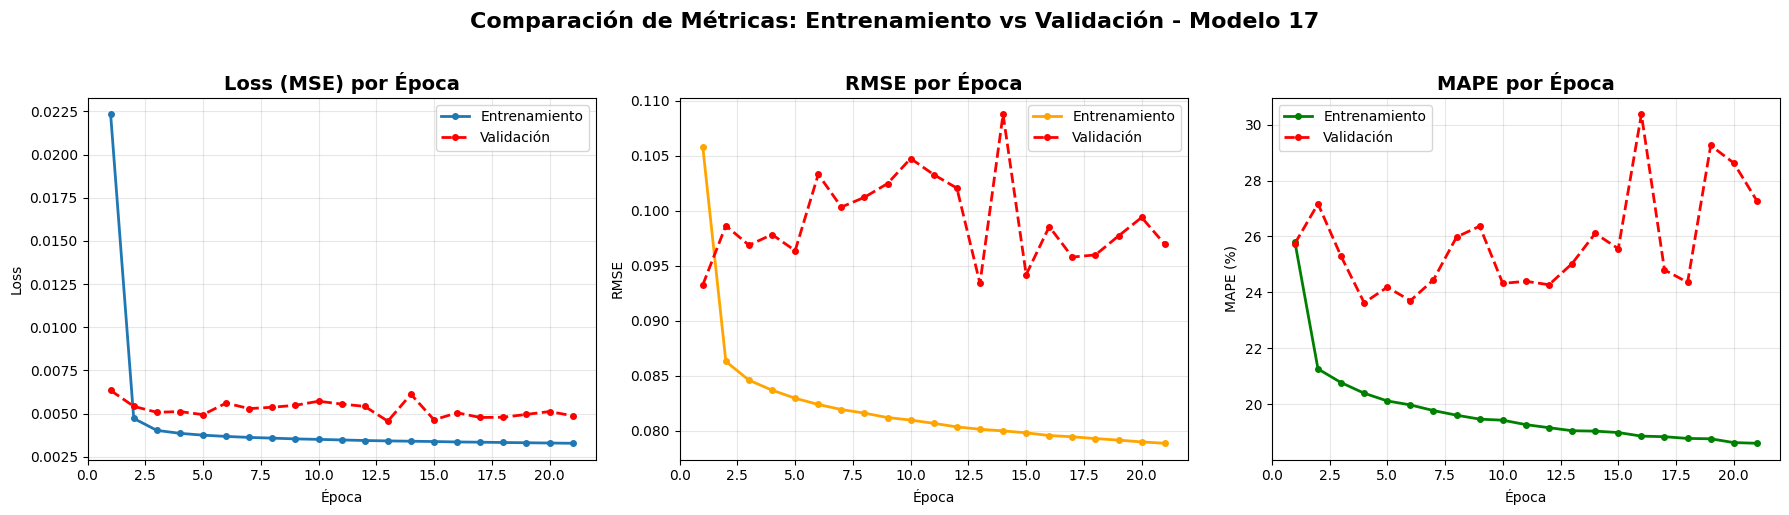

In [ ]:

# Extraer métricas del historial (entrenamiento y validación)
loss = history17_2b.history['loss']
val_loss = history17_2b.history['val_loss']

rmse = history17_2b.history['root_mean_squared_error']
val_rmse = history17_2b.history['val_root_mean_squared_error']

mape = history17_2b.history['mean_absolute_percentage_error']
val_mape = history17_2b.history['val_mean_absolute_percentage_error']

epochs = range(1, len(loss) + 1)

# Mostrar resumen final
print("=" * 50)
print("RESUMEN DE MÉTRICAS")
print("=" * 50)
print(f"Entrenamiento - Loss final: {loss[-1]:.4f}, RMSE final: {rmse[-1]:.4f}, MAPE final: {mape[-1]:.4f}")
print(f"Validación    - Loss final: {val_loss[-1]:.4f}, RMSE final: {val_rmse[-1]:.4f}, MAPE final: {val_mape[-1]:.4f}")
print("=" * 50)

# =============================================================================
# VISUALIZACIÓN DE MÉTRICAS
# =============================================================================

plt.figure(figsize=(18, 5))

# Gráfico 1: Loss (MSE)
plt.subplot(1, 3, 1)
plt.plot(epochs, loss, marker='o', label='Entrenamiento', linewidth=2, markersize=4)
plt.plot(epochs, val_loss, marker='o', linestyle='--', color='red', linewidth=2, markersize=4, label='Validación')
plt.title('Loss (MSE) por Época', fontsize=14, fontweight='bold')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.legend()

# Gráfico 2: RMSE
plt.subplot(1, 3, 2)
plt.plot(epochs, rmse, marker='o', color='orange', label='Entrenamiento', linewidth=2, markersize=4)
plt.plot(epochs, val_rmse, marker='o', linestyle='--', color='red', linewidth=2, markersize=4, label='Validación')
plt.title('RMSE por Época', fontsize=14, fontweight='bold')
plt.xlabel('Época')
plt.ylabel('RMSE')
plt.grid(True, alpha=0.3)
plt.legend()

# Gráfico 3: MAPE
plt.subplot(1, 3, 3)
plt.plot(epochs, mape, marker='o', color='green', label='Entrenamiento', linewidth=2, markersize=4)
plt.plot(epochs, val_mape, marker='o', linestyle='--', color='red', linewidth=2, markersize=4, label='Validación')
plt.title('MAPE por Época', fontsize=14, fontweight='bold')
plt.xlabel('Época')
plt.ylabel('MAPE (%)')
plt.grid(True, alpha=0.3)
plt.legend()

plt.suptitle('Comparación de Métricas: Entrenamiento vs Validación - Modelo 17 Bandas 9 y 13',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


Generando predicciones...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step


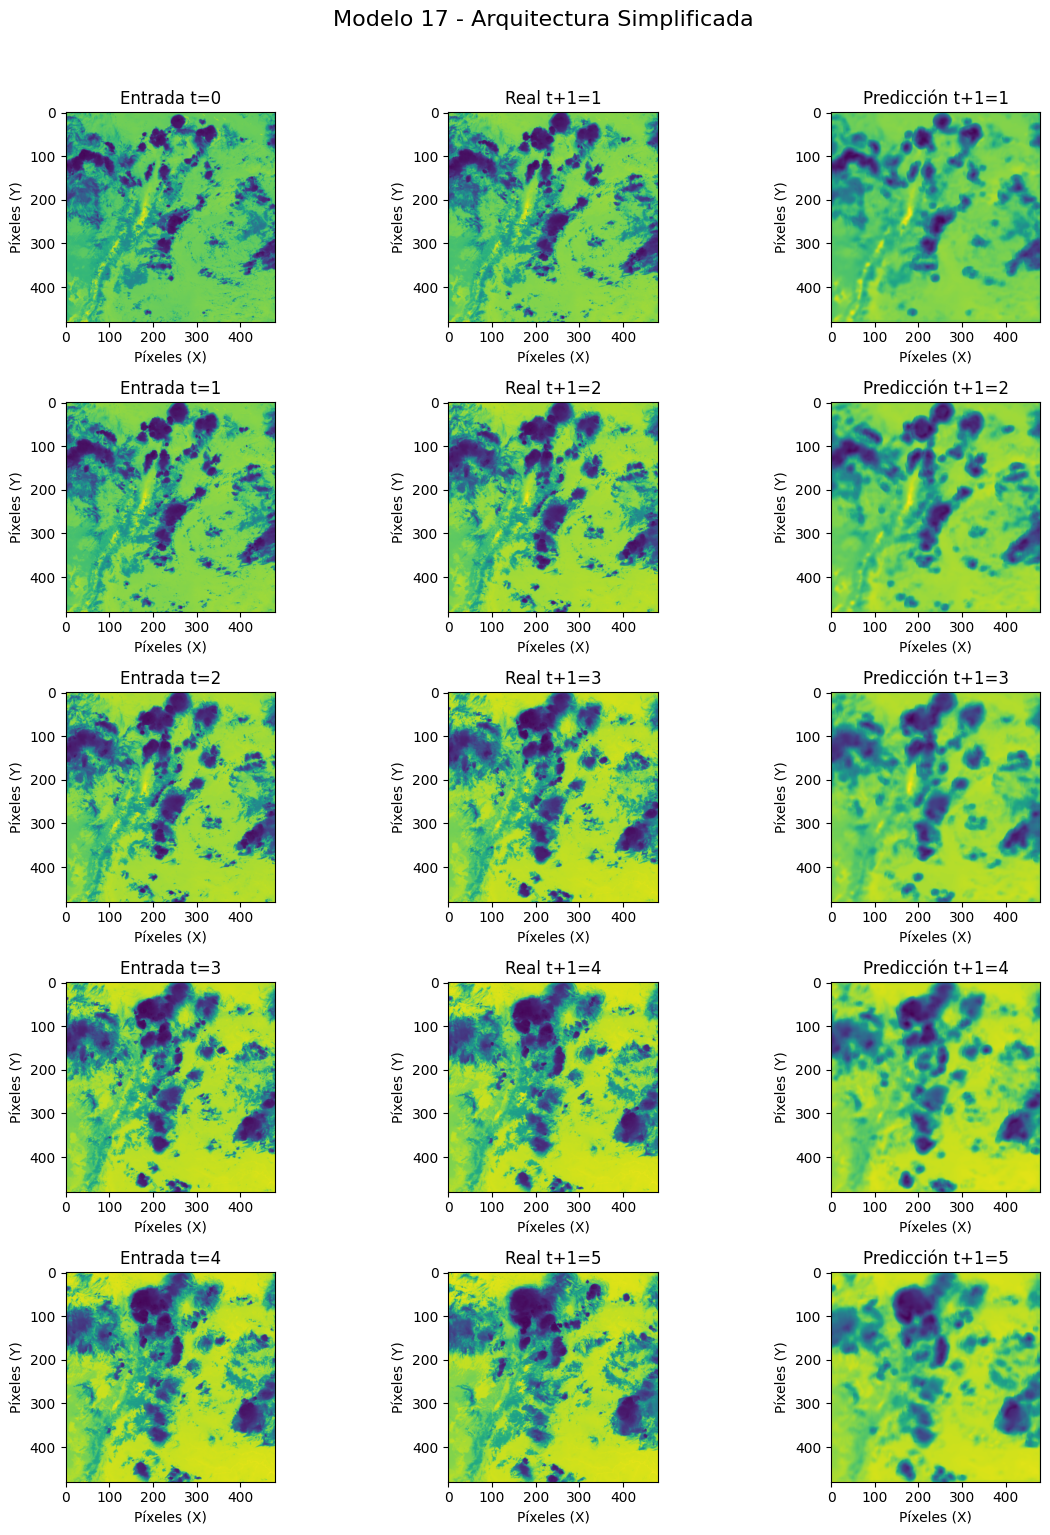

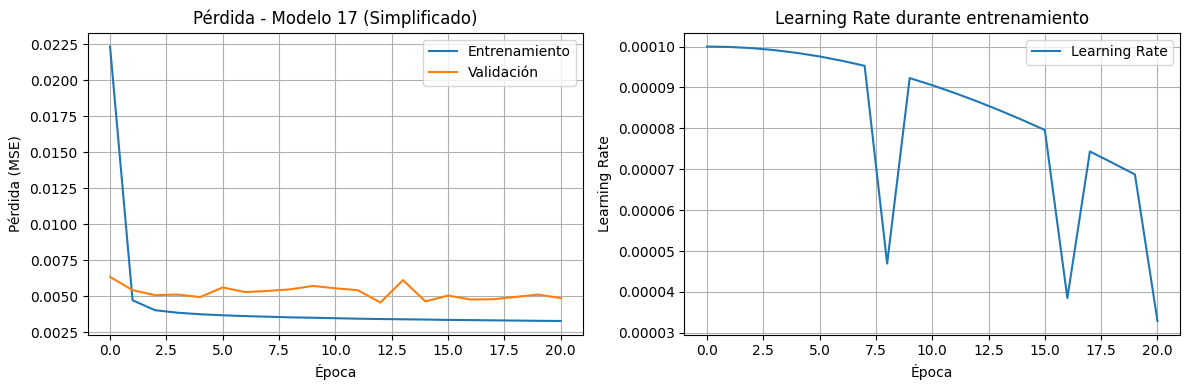

In [ ]:
# =====================================================
# VISUALIZACIÓN
# =====================================================

print("\nGenerando predicciones...")
y_pred_2b = model17_2b.predict(X_val[:10])

mostrar_resultados(
    X_val[:10, -1],
    y_val[:10],
    y_pred_2b[:10],
    n=5,
    titulo_general="Modelo 17 - Bandas 9 y 13",
    xlabel="Píxeles (X)",
    ylabel="Píxeles (Y)"
)

# Gráficas de entrenamiento
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history17_2b.history['loss'], label='Entrenamiento')
plt.plot(history17_2b.history['val_loss'], label='Validación')
plt.title('Pérdida - Modelo 17- Bandas 9 y 13')
plt.xlabel('Época')
plt.ylabel('Pérdida (MSE)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history17_2b.history['learning_rate'], label='Learning Rate')
plt.title('Learning Rate durante entrenamiento')
plt.xlabel('Época')
plt.ylabel('Learning Rate')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Datos de prueba:

In [ ]:
# Directorio original y reducido para validación
prueba_13 = '/home/jhon/bandas/banda13/nov_dic_2m'
prueba_13_red = '/home/jhon/bandas/banda13/nov_dic_2m_red'

# Llamar a la función para redimensionar imágenes
resize_npy_images(prueba_13, prueba_13_red, new_size=(480, 480))

# Cargar imágenes
file_list_test = sorted([f for f in os.listdir(prueba_13_red) if f.endswith('.npy')])
print(f"Procesando {len(file_list_test)} imágenes para validación")

images_test_13= [np.load(os.path.join(prueba_13_red, f)) for f in file_list_test]

# Normalización
all_pixels = np.concatenate([img.flatten() for img in images_test])
global_min, global_max = np.min(all_pixels), np.max(all_pixels)

images_test_13 = [(img - global_min) / (global_max - global_min + 1e-8) for img in images_test]
images_test_13 = [np.clip(img, 0, 1) for img in images_test]

# Parámetro de secuencia temporal (debe ser el mismo que en entrenamiento)
timesteps = 3

# Construir secuencias para validación: X_seq_val (N, timesteps, H, W, C), y_seq_test (N, H, W, C)
X_base_test_13 = np.array(images_test_13)[..., np.newaxis]  # (num_imgs_test, H, W, C)
y_base_test_13 = X_base_test_13.copy()  # y_base_test igual a X_base_test

N_seq_test_13 = X_base_test_13.shape[0] - timesteps
X_seq_test_13 = np.array([X_base_test_13[i:i+timesteps] for i in range(N_seq_test_13)])  # (N_seq_test, timesteps, H, W, C)
y_seq_test_13= y_base_test_13[timesteps:]  # (N_seq_test, H, W, C)

print(f"Forma de X_seq_test_13: {X_seq_test_13.shape}")  # (N_seq_test, timesteps, H, W, C)
print(f"Forma de y_seq_test_13: {y_seq_test_13.shape}")  # (N_seq_test, H, W, C)



In [ ]:

prueba_9 = '/home/jhon/bandas/banda9/nov_dic_2m'
prueba_9_red = '/home/jhon/bandas/banda9/nov_dic_2m_red'

# Llamar a la función para redimensionar imágenes
resize_npy_images(prueba_9, prueba_9_red, new_size=(480, 480))

# Cargar imágenes
file_list_test = sorted([f for f in os.listdir(prueba_9_red) if f.endswith('.npy')])
print(f"Procesando {len(file_list_test)} imágenes para validación")

images_test_9 = [np.load(os.path.join(prueba_9_red, f)) for f in file_list_test]

# Normalización
all_pixels_9 = np.concatenate([img.flatten() for img in images_test_13])
global_min_9, global_max = np.min(all_pixels_9), np.max(all_pixels_9)

images_test_9= [(img - global_min) / (global_max - global_min + 1e-8) for img in images_test_9]
images_test_9 = [np.clip(img, 0, 1) for img in images_test_9]

# Parámetro de secuencia temporal (debe ser el mismo que en entrenamiento)
timesteps = 3

# Construir secuencias para validación: X_seq_val (N, timesteps, H, W, C), y_seq_test (N, H, W, C)
X_base_test_9 = np.array(images_test_9)[..., np.newaxis]  # (num_imgs_test, H, W, C)
y_base_test_9 = X_base_test_9.copy()  # y_base_test igual a X_base_test

N_seq_test_9 = X_base_test_9.shape[0] - timesteps
X_seq_test_9 = np.array([X_base_test_9[i:i+timesteps] for i in range(N_seq_test_9)])  # (N_seq_test, timesteps, H, W, C)
y_seq_test_9= y_base_test_9[timesteps:]  # (N_seq_test, H, W, C)

print(f"Forma de X_seq_test_9: {X_seq_test_9.shape}")  # (N_seq_test, timesteps, H, W, C)
print(f"Forma de y_seq_test_9: {y_seq_test_9.shape}")  # (N_seq_test, H, W, C)

In [ ]:
# Combinar ambos conjuntos de datos
X_multi_test = np.concatenate([X_seq_test_13, X_seq_test_9], axis=-1)
y_multi_test= np.concatenate([y_seq_test_13, y_seq_test_9], axis=-1)

print("Forma de X multi test", X_multi_test.shape)
print("Forma de y multi test:", y_multi_test.shape)

In [ ]:
# Ahora puedes evaluar el modelo
loss, rmse, mape = model17_2b.evaluate(X_multi_test, y_multi_test, verbose=1)
print(f"Pérdida (MSE): {loss:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}")

46/46 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - loss: 0.0046 - mean_absolute_percentage_error: 23.6060 - root_mean_squared_error: 0.0934
Pérdida (MSE): 0.0046
RMSE: 0.0934
MAPE: 23.6060


46/46 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step


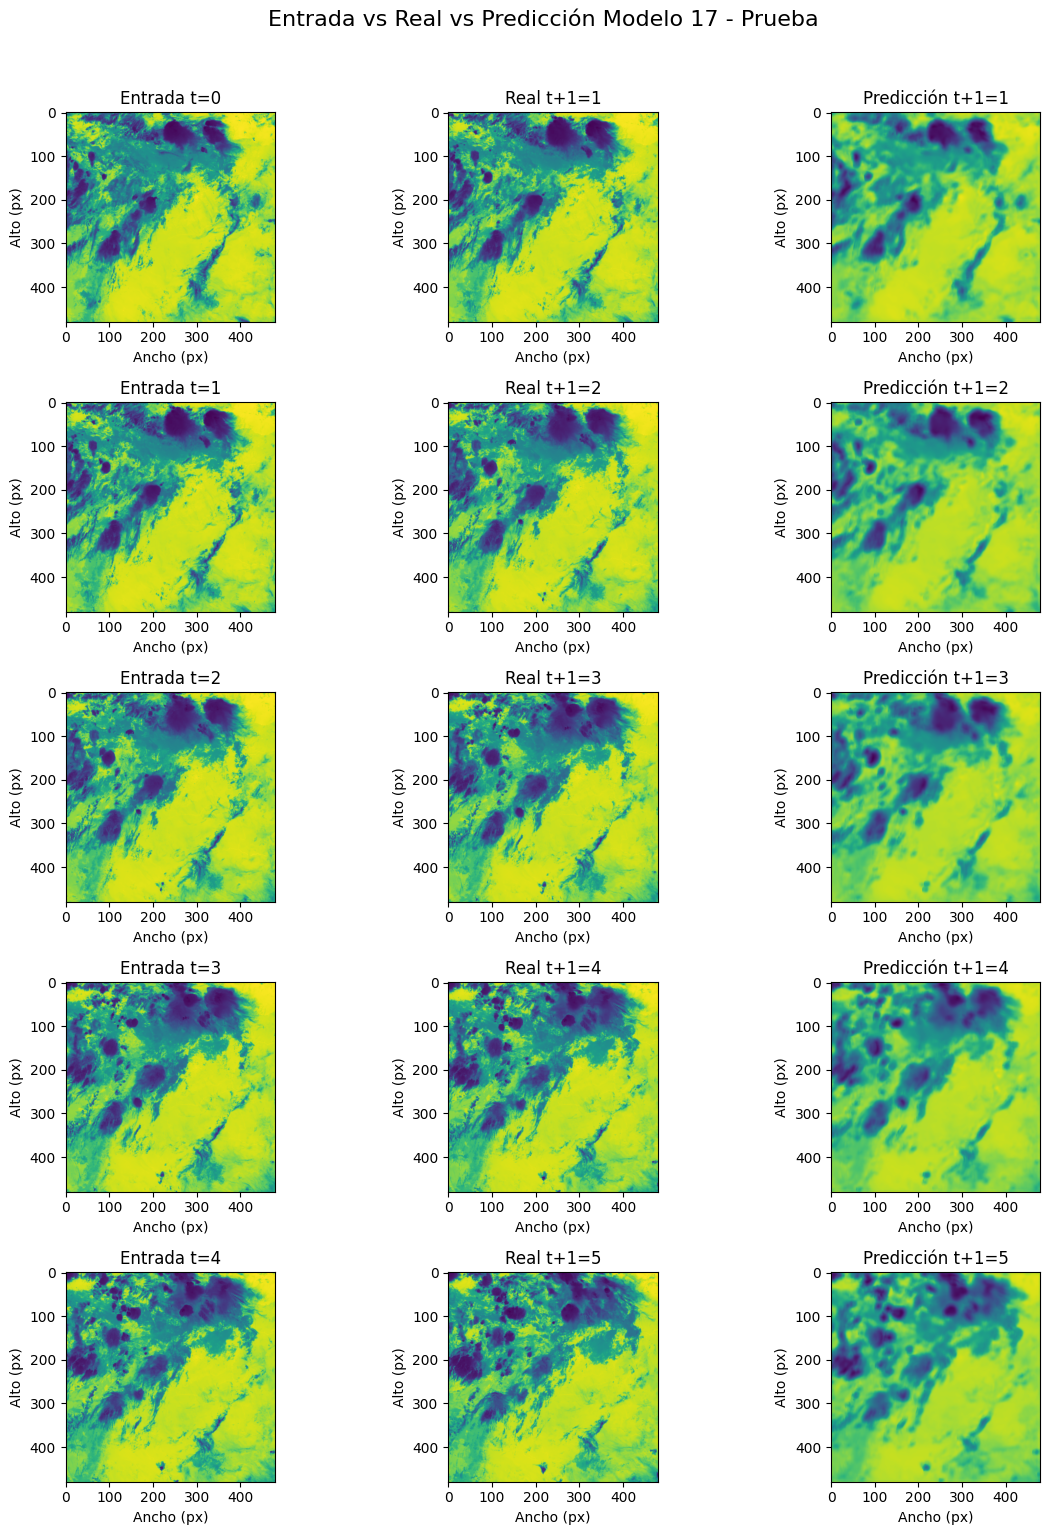

In [ ]:
y_pred17_test_2b = model17_2b.predict(X_multi_test)  # Genera las predicciones usando X_seq_val
mostrar_resultados(
    X_multi_test[:, -1, :, :, :],  # Toma solo el último timestep de la secuencia de entrada
    y_multi_test,                   # Valores reales
    y_pred17_test_2b,                # Predicciones
    n=5,
    titulo_general="Entrada vs Real vs Predicción Modelo 17 - Bandas 9 y 13 - Prueba",
    xlabel="Ancho (px)",
    ylabel="Alto (px)"
)